/kaggle/input/datasets/holzmann117j/attentiontest/test.txt
Using device: cuda
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 70.1 MB/s eta 0:00:00:00:0100:01
Total characters: 490378
Vocab size: 157
Train length: 441340
Val length: 49038

FullTransformer initial loss: 5.1740
FullTransformer | step 0: train loss 5.1598, val loss 5.1783
FullTransformer | step 300: train loss 2.3754, val loss 2.3917
FullTransformer | step 600: train loss 1.8832, val loss 1.8907
FullTransformer | step 900: train loss 1.6633, val loss 1.6622
FullTransformer | step 1200: train loss 1.5485, val loss 1.5478
FullTransformer | step 1500: train loss 1.4685, val loss 1.4796
FullTransformer | step 1800: train loss 1.4066, val loss 1.4498
FullTransformer | step 2100: train loss 1.3599, val loss 1.4125
FullTransformer | step 2400: train loss 1.3376, val loss 1.3803
FullTransformer | step 2700: train loss 1.3054, val loss 1.3726


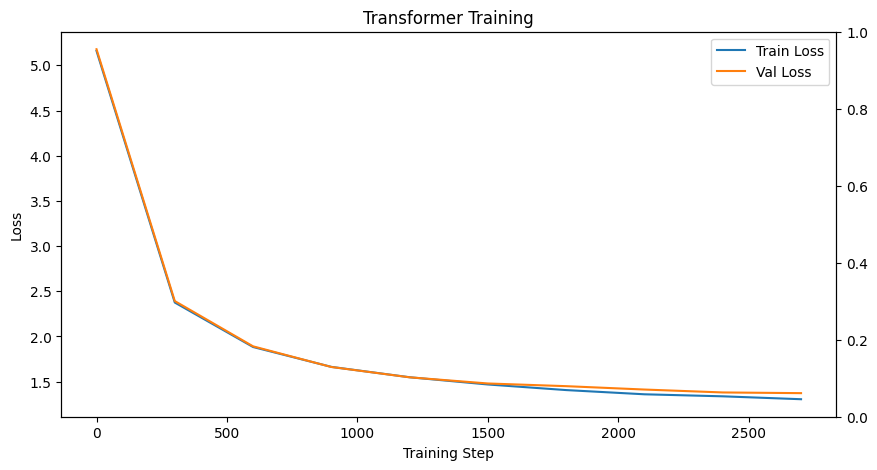

Number of chunks: 3270

Example chunk:



Wikipedia The Free Encyclopedia

    Donate
    Create account
    Log in

Contents

    (Top)
    Life
        Early life
        London and theatrical career
        Later years and death
    Play


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

=== Dense top-5 ===

chunk_id=51, dense_score=0.7884
 Shakespeare starting his theatrical career minding the horses of theatre patrons in London.[27] John Aubrey reported that Shakespeare had been a country schoolmaster.[28] Some 20th-century scholars s

chunk_id=352, dense_score=0.7988
Wilhelm Meister's Apprenticeship (1795); Stendhal's two-part pamphlet Racine et Shakespeare (1823–25); and Victor Hugo's prefaces to Cromwell (1827) and William Shakespeare (1864).[255]
    For exampl

chunk_id=64, dense_score=0.8153
eatre. Biographers suggest that his career may have begun any time from the mid-1580s to just before Greene's remarks.[38][39][40] After 1594 Shakespeare's plays were performed at The Theatre, in Shor

chunk_id=672, dense_score=0.8241
 Marlowe
    Philip Massinger
    Thomas Middleton
    Thomas More
    Thomas Nashe
    William Rowley
    William Shakespeare
    James Shirley
    Philip Sidney
    Edmund Spenser
    William Tyndal

chunk_id=54, dense_score=0.8282
ollected 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, List
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)
!pip install sentence-transformers faiss-cpu
!pip install sentence-transformers
!pip install rank-bm25
# =========================================================
# 1. Load corpus
# =========================================================
TEXT_PATH = "/kaggle/input/datasets/holzmann117j/attentiontest/test.txt" 

with open(TEXT_PATH, "r", encoding="utf-8") as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s if c in stoi]

def decode(token_ids):
    return ''.join([itos[i] for i in token_ids])

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Total characters:", len(text))
print("Vocab size:", vocab_size)
print("Train length:", len(train_data))
print("Val length:", len(val_data))

# =========================================================
# 2. Hyperparameters
# =========================================================
batch_size = 32
block_size = 128
n_embd = 128
n_heads = 4
head_size = n_embd // n_heads
n_layer = 3
dropout = 0.1
max_iters = 3000
eval_interval = 300
learning_rate = 2e-3
eval_iters = 100

# =========================================================
# 3. Batch function
# =========================================================
def get_batch(split):
    data_source = train_data if split == 'train' else val_data
    max_start = len(data_source) - block_size - 1

    if max_start <= 0:
        raise ValueError(
            f"{split} data too short. len={len(data_source)}, need at least {block_size + 2}"
        )

    ix = torch.randint(0, max_start, (batch_size,))
    x = torch.stack([data_source[i:i+block_size] for i in ix])
    y = torch.stack([data_source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# =========================================================
# 4. Attention head
# =========================================================
class SelfAttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, block_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x, return_weights=False):
        B, T, C = x.shape

        K = self.key(x)                                    # (B, T, head_size)
        Q = self.query(x)                                  # (B, T, head_size)
        V = self.value(x)                                  # (B, T, head_size)

        scores = Q @ K.transpose(-2, -1)                   # (B, T, T)
        scores = scores / math.sqrt(K.shape[-1])
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))

        weights = F.softmax(scores, dim=-1)                # (B, T, T)
        weights = self.dropout(weights)
        out = weights @ V                                  # (B, T, head_size)

        if return_weights:
            return out, weights
        return out

# =========================================================
# 5. Multi-head attention
# =========================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, head_size, n_embd, block_size):
        super().__init__()
        self.heads = nn.ModuleList([
            SelfAttentionHead(n_embd, head_size, block_size)
            for _ in range(n_heads)
        ])
        self.proj = nn.Linear(n_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout) 
        
    def forward(self, x, return_weights=False):
        if return_weights:
            head_outputs = []
            head_weights = []

            for h in self.heads:
                out, weights = h(x, return_weights=True)
                head_outputs.append(out)
                head_weights.append(weights)

            out = torch.cat(head_outputs, dim=-1)          # (B, T, n_embd)
            out = self.proj(out)                           # (B, T, n_embd)
            weights = torch.stack(head_weights, dim=1)     # (B, n_heads, T, T)
            return out, weights

        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)  
        return out

# =========================================================
# 6. Feed-forward network
# =========================================================
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Dropout(dropout), 
            nn.Linear(4 * n_embd, n_embd),
        )

    def forward(self, x):
        return self.net(x)

# =========================================================
# 7. Transformer block
# =========================================================
class Block(nn.Module):
    def __init__(self, n_embd, n_heads, block_size):
        super().__init__()
        head_size = n_embd // n_heads
        self.ln1 = nn.LayerNorm(n_embd)
        self.sa = MultiHeadAttention(n_heads, head_size, n_embd, block_size)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward(n_embd)

    def forward(self, x, return_weights=False):
        if return_weights:
            attn_out, weights = self.sa(self.ln1(x), return_weights=True)
            x = x + attn_out
            x = x + self.ffwd(self.ln2(x))
            return x, weights

        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# =========================================================
# 8. Full Transformer language model
# =========================================================
class TransformerLanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_heads, n_layer):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        self.blocks = nn.ModuleList([
            Block(n_embd, n_heads, block_size) for _ in range(n_layer)
        ])

        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None, return_weights=False):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding_table(pos)
        x = tok_emb + pos_emb

        all_weights = []

        for i, block in enumerate(self.blocks):
            if return_weights and i == 0:
                x, weights = block(x, return_weights=True)
                all_weights.append(weights)
            else:
                x = block(x)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        if return_weights:
            return logits, loss, all_weights
        return logits, loss

    
    
    
    def generate(self, idx, max_new_tokens, block_size):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        return idx

# =========================================================
# 9. Loss estimation
# =========================================================
@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()

    model.train()
    return out

# =========================================================
# 10. Training function
# =========================================================
def train_model(model, name):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    history = {"step": [], "train_loss": [], "val_loss": []}

    xb, yb = get_batch('train')
    _, init_loss = model(xb, yb)
    print(f"\n{name} initial loss: {init_loss.item():.4f}")

    for step in range(max_iters):
        if step % eval_interval == 0:
            losses = estimate_loss(model)
            history["step"].append(step)
            history["train_loss"].append(losses["train"])
            history["val_loss"].append(losses["val"])
            print(f"{name} | step {step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        xb, yb = get_batch('train')
        _, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return model, history

# =========================================================
# 11. Create and train
# =========================================================
model_transformer = TransformerLanguageModel(
    vocab_size=vocab_size,
    n_embd=n_embd,
    block_size=block_size,
    n_heads=n_heads,
    n_layer=n_layer
)

model_transformer, history_transformer = train_model(model_transformer, "FullTransformer")



# =========================================================
# 12. Plot losses
# =========================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(history_transformer["step"], history_transformer["train_loss"], label="Train Loss")
ax1.plot(history_transformer["step"], history_transformer["val_loss"], label="Val Loss")
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax2 = ax1.twinx()
plt.title("Transformer Training")
plt.show()

model = TransformerLanguageModel(vocab_size, n_embd, block_size, n_heads, n_layer)


# =========================================================
# 18. RAG - definition of chunks
# =========================================================

def chunk_text(text, chunk_size=200, overlap=50):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)

        start += chunk_size - overlap

    return chunks

chunks = chunk_text(text, chunk_size=200, overlap=50)

print("Number of chunks:", len(chunks))
print("\nExample chunk:\n")
print(chunks[0])


# =========================================================
# 19. RAG - MiniLM Embeddings
# =========================================================
import faiss
import numpy as np

from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

chunk_embeddings = embed_model.encode(chunks, convert_to_numpy=True)

print("Embedding shape:", chunk_embeddings.shape)

d = chunk_embeddings.shape[1]
nlist = 50  # number of clusters

quantizer = faiss.IndexFlatL2(d)
ivf_index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)

# train the IVF index on your embeddings
ivf_index.train(chunk_embeddings)

# add vectors
ivf_index.add(chunk_embeddings)

# =========================================================
# 19.1 RAG - BM25 Lexical Retriever
# =========================================================
from rank_bm25 import BM25Okapi
import re

def simple_tokenize(text):
    return re.findall(r"\w+", text.lower())

tokenized_chunks = [simple_tokenize(chunk) for chunk in chunks]
bm25 = BM25Okapi(tokenized_chunks)

# =========================================================
# 19.2 RAG - BM25 Retrieval
# =========================================================
def retrieve_bm25(query, k=10, **kwargs):
    query_tokens = simple_tokenize(query)
    scores = bm25.get_scores(query_tokens)

    top_indices = scores.argsort()[-k:][::-1]

    results = []
    for idx in top_indices:
        results.append((chunks[idx], float(scores[idx]), int(idx)))
    return results

# =========================================================
# 20.4 RAG - Union of Dense + BM25 candidates
# =========================================================
def union_candidates(dense_results, bm25_results):
    merged = {}

    for chunk_text, score, chunk_id in dense_results:
        merged[chunk_id] = chunk_text

    for chunk_text, score, chunk_id in bm25_results:
        merged[chunk_id] = chunk_text

    return [(chunk_text, chunk_id) for chunk_id, chunk_text in merged.items()]
# =========================================================
# RAG - Reranker (Cross Encoder)
# =========================================================
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
# =========================================================
# 20.5 RAG - Rerank union candidates
# =========================================================
def rerank_union(query, unioned_candidates):
    """
    unioned_candidates:
        [(chunk_text, chunk_id), ...]
    Returns:
        [(chunk_text, rerank_score, chunk_id), ...]
    """
    pairs = [(query, chunk_text) for chunk_text, chunk_id in unioned_candidates]
    scores = reranker.predict(pairs)

    reranked = []
    for i, (chunk_text, chunk_id) in enumerate(unioned_candidates):
        reranked.append((chunk_text, float(scores[i]), int(chunk_id)))

    reranked.sort(key=lambda x: x[1], reverse=True)
    return reranked
        
query = "What was John Shakespeare's profession?"
    
def retrieve_ivf(query, k=10, **kwargs):
    query_vec = embed_model.encode([query], convert_to_numpy=True)
    distances, indices = ivf_index.search(query_vec, k)

    results = []
    for i, idx in enumerate(indices[0]):
        results.append((chunks[idx], float(distances[0][i]), int(idx)))
    return results

dense_results = retrieve_ivf(query, k=10)
bm25_results = retrieve_bm25(query, k=10)

print("=== Dense top-5 ===\n")
for chunk_text, score, chunk_id in dense_results[:5]:
    print(f"chunk_id={chunk_id}, dense_score={score:.4f}")
    print(chunk_text[:220])
    print()

print("\n=== BM25 top-5 ===\n")
for chunk_text, score, chunk_id in bm25_results[:5]:
    print(f"chunk_id={chunk_id}, bm25_score={score:.4f}")
    print(chunk_text[:220])
    print()

unioned = union_candidates(dense_results, bm25_results)

print(f"\nNumber of unique union candidates: {len(unioned)}\n")

reranked_union = rerank_union(query, unioned)

print("=== Reranked union top-5 ===\n")
for chunk_text, score, chunk_id in reranked_union[:5]:
    print(f"chunk_id={chunk_id}, rerank_score={score:.4f}")
    print(chunk_text[:220])
    print()



# =========================================================
# 21. RAG - Prompt Construction
# =========================================================
def build_rag_prompt(query, reranked_results, top_k=3):
    selected = reranked_results[:top_k]

    context_text = "\n\n".join(
        [f"[Chunk {i+1} | rerank_score={score:.4f}]\n{chunk_text}"
         for i, (chunk_text, score, chunk_id) in enumerate(selected)]
    )

    prompt = f"""Answer the question using only the retrieved context below.

Retrieved Context:
{context_text}

Question:
{query}

Answer:"""

    return prompt
    
reranked = rerank_union(query, unioned)

class RetrieverWrapper:
    def __init__(self, search_func):
        self.search_func = search_func
    def search(self, question, **kwargs):
        # We accept 'top_k' here so the code doesn't crash, 
        # but we only pass 'question' to your original function.
        return self.search_func(question, **kwargs)
# Wrap your functions
dense_retriever = RetrieverWrapper(retrieve_ivf)
bm25_retriever = RetrieverWrapper(retrieve_bm25)

class CharTokenizerAdapter:
    def __init__(self, stoi, itos, unknown_token_id=None):
        self.stoi = stoi
        self.itos = itos
        self.unknown_token_id = unknown_token_id

    def encode(self, text: str):
        ids = []
        for ch in text:
            if ch in self.stoi:
                ids.append(self.stoi[ch])
            else:
                if self.unknown_token_id is not None:
                    ids.append(self.unknown_token_id)
                # otherwise skip unknown chars
        return ids

    def decode(self, ids):
        return ''.join(self.itos[i] for i in ids if i in self.itos)



class SmallLMAdapter:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def generate(
        self,
        input_ids,
        max_new_tokens=64,
        temperature=1.0,
        top_k=None,
    ):
        """
        input_ids: list[int]
        returns: list[int]
        """
        self.model.eval()
        self.model = self.model.to("cuda")
        idx = torch.tensor([input_ids], dtype=torch.long, device=device)

        with torch.no_grad():
            # If your original model.generate only accepts (idx, max_new_tokens),
            # start with that first.
            out = self.model.generate(idx, max_new_tokens=max_new_tokens, block_size=128)

        # convert from shape (1, T) to python list
        return out[0].tolist()



@dataclass
class RetrievedChunk:
    chunk_id: str
    text: str
    source: Optional[str] = None
    dense_score: float = 0.0
    bm25_score: float = 0.0
    rerank_score: float = 0.0
    metadata: Dict[str, Any] = field(default_factory=dict)


@dataclass
class SentenceCandidate:
    chunk_id: str
    sentence_id: int
    text: str
    chunk_rerank_score: float = 0.0
    sentence_score: float = 0.0
    final_score: float = 0.0


@dataclass
class AnswerResult:
    question: str
    answer: str
    supported: bool
    confidence: float
    mode: str  # "extractive", "generative", "extractive_fallback", "refusal"
    evidence_sentences: List[str] = field(default_factory=list)
    debug: Dict[str, Any] = field(default_factory=dict)



class MiniRAG:
    def __init__(
        self,
        dense_retriever=None,
        bm25_retriever=None,
        cross_encoder=None,
        small_lm=None,
        tokenizer=None,
        top_n_retrieval: int = 8,
        top_n_rerank: int = 4,
        top_k_evidence: int = 3,
        evidence_threshold: float = 0.5,
        sentence_alpha: float = 0.8,
        chunk_beta: float = 0.2,
        debug: bool = True,
    ):
        self.dense_retriever = dense_retriever
        self.bm25_retriever = bm25_retriever
        self.cross_encoder = cross_encoder
        self.small_lm = small_lm
        self.tokenizer = tokenizer

        self.top_n_retrieval = top_n_retrieval
        self.top_n_rerank = top_n_rerank
        self.top_k_evidence = top_k_evidence
        self.evidence_threshold = evidence_threshold
        self.sentence_alpha = sentence_alpha
        self.chunk_beta = chunk_beta
        self.debug = debug

        self.answer_cache = {}



    def retrieve_candidates(self, question: str) -> List[RetrievedChunk]:

        dense_results = []
        bm25_results = []

        if self.dense_retriever is not None:
            dense_results = self.dense_retriever.search(question, top_k=self.top_n_retrieval)

        if self.bm25_retriever is not None:
            bm25_results = self.bm25_retriever.search(question, top_k=self.top_n_retrieval)

        merged = {}

        for item in dense_results:
            cid = item[2]
            if cid not in merged:
                merged[cid] = RetrievedChunk(
                    chunk_id=cid,
                    text=item[0],
                    source=None,
                    dense_score=float(item[1],)  
                ) 
            else:
                merged[cid].dense_score = float(item[1])

        for item in bm25_results:
            cid = item[2]
            if cid not in merged:
                merged[cid] = RetrievedChunk(
                    chunk_id=cid,
                    text=item[0],
                    source=None,
                    bm25_score=float(item[1])
                )
            else:
                merged[cid].bm25_score = float(item[1])

        return list(merged.values())



    def rerank_chunks(self, question: str, chunks: List[RetrievedChunk]) -> List[RetrievedChunk]:
        if not chunks:
            return []

        if self.cross_encoder is None:
            # fallback: simple hybrid if no cross-encoder
            for ch in chunks:
                ch.rerank_score = 0.5 * ch.dense_score + 0.5 * ch.bm25_score
            return sorted(chunks, key=lambda x: x.rerank_score, reverse=True)

        pairs = [(question, ch.text) for ch in chunks]
        scores = self.cross_encoder.predict(pairs)

        for ch, score in zip(chunks, scores):
            ch.rerank_score = float(score)

        chunks = sorted(chunks, key=lambda x: x.rerank_score, reverse=True)
        return chunks[:self.top_n_rerank]
 

    def simple_sentence_split(self, text: str) -> List[str]:
        text = re.sub(r"\s+", " ", text).strip()
        if not text:
            return []

        sentences = re.split(r'(?<=[.!?])\s+', text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
        return sentences


    def build_sentence_candidates(self, chunks: List[RetrievedChunk]) -> List[SentenceCandidate]:
        candidates = []
        for chunk in chunks:
            sentences = self.simple_sentence_split(chunk.text)
            for i, sent in enumerate(sentences):
                candidates.append(
                    SentenceCandidate(
                        chunk_id=chunk.chunk_id,
                        sentence_id=i,
                        text=sent,
                        chunk_rerank_score=chunk.rerank_score,
                    ))
        return candidates
        
    def print_ranked(self, items, formatter, n=10, title=None):
        if title:
            print(f"\n=== {title} ===")
        
        lines = [
            f"{i}. {formatter(item)}"
            for i, item in enumerate(items[:n], start=1)
        ]
        print("\n".join(lines))


    def score_sentences(self, question: str, candidates: List[SentenceCandidate]) -> List[SentenceCandidate]:
        if not candidates:
            return []

        if self.cross_encoder is None:
            # crude fallback if no cross-encoder
            for cand in candidates:
                cand.sentence_score = cand.chunk_rerank_score
                cand.base_score = cand.sentence_score
                cand.heuristic_score = (
                    self.relation_bonus(question, cand.text)
                    + self.profession_bonus(question, cand.text)
                    - self.vagueness_penalty(cand.text)
                )
                cand.heuristic_score = max(min(cand.heuristic_score, 2.0), -2.0)
                cand.final_score = cand.base_score + cand.heuristic_score

            return sorted(candidates, key=lambda c: c.final_score, reverse=True)

        pairs = [(question, cand.text) for cand in candidates]
        scores = self.cross_encoder.predict(pairs)

        for cand, score in zip(candidates, scores):
            cand.sentence_score = float(score)
            cand.base_score = (self.sentence_alpha * cand.sentence_score + self.chunk_beta * cand.chunk_rerank_score)
            cand.heuristic_score = (self.relation_bonus(question, cand.text) + self.profession_bonus(question, cand.text)- self.vagueness_penalty(cand.text))
            cand.heuristic_score = max(min(cand.heuristic_score, 2.0), -2.0)
            cand.final_score = (cand.base_score + cand.heuristic_score)
        return sorted(candidates, key=lambda c: c.final_score, reverse=True)

    def deduplicate_sentences( self, candidates: List[SentenceCandidate], max_overlap_ratio: float = 0.8) -> List[SentenceCandidate]:
        selected = []
        seen_word_sets = []

        for cand in candidates:
            words = set(cand.text.lower().split())
            is_duplicate = False

            for prev_words in seen_word_sets:
                overlap = len(words & prev_words) / max(1, len(words))
                if overlap >= max_overlap_ratio:
                    is_duplicate = True
                    break

            if not is_duplicate:
                selected.append(cand)
                seen_word_sets.append(words)

        return selected


    def select_evidence(self, candidates: List[SentenceCandidate]) -> List[SentenceCandidate]:
        strong_candidates = [
            c for c in candidates
            if c.final_score >= self.evidence_threshold
        ]

        selected = strong_candidates[:self.top_k_evidence]

        if self.debug:
            self.print_ranked(
                selected,
                lambda e: (
                    f"chunk={e.chunk_id} | "
                    f"sent={e.sentence_id} | "
                    f"base={e.base_score:.2f} | "
                    f"heuristic={e.heuristic_score:.2f} | "
                    f"final={e.final_score:.2f} | "
                    f"text={e.text[:80]}"
                ),
                title="Selected Evidence"
             )     
        return selected



    def compute_confidence(self, evidence: List[SentenceCandidate]) -> float:
        if not evidence:
            return 0.0
        return float(evidence[0].final_score)

    def evidence_is_sufficient(self, evidence: List[SentenceCandidate]) -> bool:
        if not evidence:
            return False
        return evidence[0].final_score >= self.evidence_threshold

    def find_profession_evidence(self, question, evidence_sentences):
        q = question.lower()

        if not ("john shakespeare" in q and ("profession" in q or "occupation" in q or "job" in q)):
            return None

        for e in evidence_sentences:
            if "john shakespeare" in e.text.lower():
                answer = self.extract_profession_answer(question, e.text)
                if answer:
                    return answer, e

        return None


    def extract_person_name(self, text: str):
        stopwords = {
        "The", "A", "An", "In", "On", "At", "His", "Her",
        "This", "That", "These", "Those"
        }

        matches = re.findall(r'\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)\b', text)
        cleaned = [m for m in matches if m.split()[0] not in stopwords]

        if cleaned:
            return cleaned[0]

        single_matches = re.findall(r'\b([A-Z][a-z]+)\b', text)
        for m in single_matches:
            if m not in stopwords:
                return m

        return None


    def analyze_query(self, question: str):
        q = question.lower().strip()

        info = {
            "question_type": None,
            "expected_answer_type": "sentence",
            "relation": None,
            "target_entity": None,
        }

        first_word = q.split()[0] if q.split() else ""
        info["question_type"] = first_word

    # family relations
        if "father" in q:
            info["relation"] = "father"
            info["expected_answer_type"] = "person"
            return info

        if "mother" in q:
            info["relation"] = "mother"
            info["expected_answer_type"] = "person"
            return info

    # profession / occupation
        if any(word in q for word in ["profession", "occupation", "job", "living"]):
            info["relation"] = "profession"
            info["expected_answer_type"] = "profession"
            return info

    # date / year
        if q.startswith("when") or "what year" in q:
            info["expected_answer_type"] = "date"
            return info

    # number
        if q.startswith("how many"):
            info["expected_answer_type"] = "number"
            return info

    # location
        if q.startswith("where"):
            info["expected_answer_type"] = "location"
            if "born" in q:
                info["relation"] = "birthplace"
            return info

    # person
        if q.startswith("who"):
            info["expected_answer_type"] = "person"
            return info

    # explanation / definition
        if q.startswith("why") or q.startswith("how"):
            info["expected_answer_type"] = "explanation"
            return info

        if q.startswith("what"):
            info["expected_answer_type"] = "definition"
            return info

        return info

    def try_extractive_answer(self, question: str, evidence_sentences):
        if not evidence_sentences:
            return None

        query_info = self.analyze_query(question)
        best = evidence_sentences[0].text.strip()

    # 1. relation-specific extraction
        if query_info["relation"] in {"father", "mother"}:
            answer = self.extract_family_relation_answer(question, best)
            if answer:
                return answer

    # 2. profession extraction
        if query_info["expected_answer_type"] == "profession":
            answer = self.extract_profession_from_evidence_list(question, evidence_sentences)
            if answer:
                return answer

    # 3. date extraction
        if query_info["expected_answer_type"] == "date":
            answer = self.extract_date_answer(best)
            if answer:
                return answer

    # 4. number extraction
        if query_info["expected_answer_type"] == "number":
            answer = self.extract_number_answer(best)
            if answer:
                return answer

    # 5. location extraction
        if query_info["expected_answer_type"] == "location":
            answer = self.extract_location_answer(question, best)
            if answer:
                return answer

    # 6. person extraction
        if query_info["expected_answer_type"] == "person":
            answer = self.extract_person_name(best)
            if answer:
                return answer

    # 7. explanation / definition fallback
        if query_info["expected_answer_type"] in {"definition", "explanation"}:
            return best

        return best

    def print_top_candidates(self, candidates, n=10):
        lines = [
            f"{i}. chunk_id={c.chunk_id} | "
            f"sent_id={c.sentence_id} | "
            f"base={c.base_score:.2f} | "
        f"heuristic={c.heuristic_score:.2f} | "
        f"final={c.final_score:.2f} | "
        f"text={c.text[:100]}"
        for i, c in enumerate(candidates[:n], start=1)
        ]

        print("\n".join(lines))

    def relation_bonus(self, question: str, sentence: str) -> float:
        q = question.lower()
        s = sentence.lower()

        bonus = 0.0

           # father questions
        if "father" in q:
        # strongest: direct identity relation
            if "was the son of" in s:
                bonus += 3.0
            elif "son of" in s:
                bonus += 2.5

        # medium: explicit father pattern
            if "his father," in s:
                bonus += 1.2
            elif "father was" in s:
                bonus += 1.5
            elif "father," in s:
                bonus += 1.0

        # small bonus if a full person name appears
            if re.search(r'\b[A-Z][a-z]+\s+[A-Z][a-z]+\b', sentence):
                bonus += 0.3

        if "mother" in q:
            if "was the daughter of" in s:
                bonus += 3.0
            elif "daughter of" in s:
                bonus += 2.5

            if "his mother," in s:
                bonus += 1.2
            elif "mother was" in s:
                bonus += 1.5
            elif "mother," in s:
                bonus += 1.0

            if re.search(r'\b[A-Z][a-z]+\s+[A-Z][a-z]+\b', sentence):
                bonus += 0.3

        return bonus

    def target_entity_bonus(self, question: str, sentence: str) -> float:
        q = question.lower()
        s = sentence.lower()

        bonus = 0.0

        if "john shakespeare" in q and "john shakespeare" in s:
            bonus += 2.0

        return bonus
    
    def profession_bonus(self, question: str, sentence: str) -> float:
        q = question.lower()
        s = sentence.lower()
        if not ("profession" in q or "occupation" in q or "job" in q):
            return 0.0

    # for this query type, prefer evidence about the target entity
        if "john shakespeare" not in s:
            return 0.0
        bonus = 0.0

        profession_terms = [
            "profession", "occupation", "job", "worked as", "was a",
            "alderman", "glover", "glove-maker", "merchant", "teacher",
            "schoolmaster", "lawyer", "doctor", "writer", "poet"
        ]

        lexical_hits = sum(1 for term in profession_terms if term in s)
        bonus += min(lexical_hits * 0.3, 1.0)

        pattern_bonus = 0.0

        if re.search(r"john shakespeare,\s+an?\s+", s):
            pattern_bonus = max(pattern_bonus, 1.5)

        if re.search(r"john shakespeare.*glover", s):
            pattern_bonus = max(pattern_bonus, 1.5)

        if re.search(r"john shakespeare.*alderman", s):
            pattern_bonus = max(pattern_bonus, 1.2)

        bonus += pattern_bonus

        return min(bonus, 2.5)

    def clean_profession_phrase(self, text: str) -> str:
        stop_phrases = [
            " originally from ",
            " from ",
            " in ",
            " who ",
            " and mary arden"
        ]

        cleaned = text
        lower_cleaned = cleaned.lower()

        cut_positions = []
        for phrase in stop_phrases:
            pos = lower_cleaned.find(phrase)
            if pos != -1:
                cut_positions.append(pos)

        if cut_positions:
            cleaned = cleaned[:min(cut_positions)]

        return cleaned.strip(" ,.")
    
    def vagueness_penalty(self, sentence: str) -> float:
        s = sentence.lower()
        penalty = 0.0

        vague_patterns = [
            "the strongest evidence",
            "might be",
            "some scholars",
            "it is believed",
            "it is thought",
            "possibly",
            "perhaps",
            "suggests that",
        ]

        for pat in vague_patterns:
            if pat in s:
                penalty += 0.8

        return penalty

    def build_prompt(self, question: str, evidence_sentences: List[SentenceCandidate]) -> str:
        lines = [f"question: {question}", "", "evidence_sentences:"]

        for cand in evidence_sentences:
            lines.append(f"- {cand.text}")

        lines.extend([
            "",
            'rule: answer only from evidence.',
            'rule: if evidence is insufficient, say "not enough evidence."',
            "",
            "answer:"
        ])

        return "\n".join(lines)
        
    def generate_with_small_lm(self, prompt: str, max_new_tokens: int = 64, temperature: float = 0.7, top_k: int = 20,) -> str:
        if self.small_lm is None or self.tokenizer is None:
            return ""

        input_ids = self.tokenizer.encode(prompt)

        # Adapt this to your own model.generate(...)
        output_ids = self.small_lm.generate(input_ids=input_ids, max_new_tokens=max_new_tokens, temperature=temperature, top_k=top_k)

        full_text = self.tokenizer.decode(output_ids)
        print("PROMPT START:", repr(prompt[:100]))
        print("FULL START:", repr(full_text[:100]))
        print("STARTSWITH:", full_text.startswith(prompt))
        # remove prompt echo
        if "answer:" in full_text:
            answer = full_text.split("answer:")[-1].strip()
        elif full_text.startswith(prompt):
            answer = full_text[len(prompt):].strip()
        else:
            answer = full_text.strip()

        # keep only first line
        answer = answer.split("\n")[0].strip()

        return answer

    def lexical_support_ratio(self, answer: str, evidence_sentences: List[SentenceCandidate]) -> float:
        if not answer or not evidence:
            return 0.0

        answer_words = set(answer.lower().split())
        if not answer_words:
            return 0.0

        evidence_words = set()
        for cand in evidence_sentences:
            evidence_words.update(cand.text.lower().split())

        return len(answer_words & evidence_words) / len(answer_words)

    def verify_answer(self, answer: str, evidence_sentences: List[SentenceCandidate], min_ratio: float = 0.5) -> bool:
        if not answer:
            return False
        return self.lexical_support_ratio(answer, evidence_sentences) >= min_ratio


    def get_from_cache(self, question: str) -> Optional[AnswerResult]:
        return self.answer_cache.get(question)

    def save_to_cache(self, question: str, result: AnswerResult):
        self.answer_cache[question] = result



    def answer(self, question: str, use_cache: bool = True) -> AnswerResult:
        if use_cache:
            cached = self.get_from_cache(question)
            if cached is not None:
                return cached

        debug_info = {}

        # 1. retrieve
        retrieved = self.retrieve_candidates(question)
        debug_info["num_retrieved"] = len(retrieved)

        if not retrieved:
            result = AnswerResult(question=question, answer="not enough evidence.", supported=False, confidence=0.0, mode="refusal", evidence_sentences=[],debug=debug_info)
            self.save_to_cache(question, result)
            return result

        # 2. rerank chunks
        top_chunks = self.rerank_chunks(question, retrieved)
        debug_info["top_chunks"] = [{"chunk_id": ch.chunk_id, "rerank_score": ch.rerank_score, "text_preview": ch.text[:200]} for ch in top_chunks]

        print("\n=== Top chunks before sentence split ===")
        for ch in top_chunks:
            print(f"chunk_id={ch.chunk_id}, rerank_score={ch.rerank_score:.4f}")
        # 3. sentence candidates
        sentence_candidates = self.build_sentence_candidates(top_chunks)
        debug_info["num_sentence_candidates"] = len(sentence_candidates)

        if not sentence_candidates:
            result = AnswerResult(question=question, answer="not enough evidence.", supported=False, confidence=0.0, mode="refusal", evidence_sentences=[], debug=debug_info)
            self.save_to_cache(question, result)
            return result

        self.top_sentence_candidates = sorted(sentence_candidates, key=lambda x: x.final_score, reverse=True)

        print("\n=== Sentence candidates right after build ===")
        for cand in sentence_candidates[:10]:
            print(
                f"chunk_id={cand.chunk_id}, "
                f"chunk_rerank_score={cand.chunk_rerank_score:.4f}, "
                f"text={cand.text[:120]}"
            )

        # 4. score sentences
        sentence_candidates = self.score_sentences(question, sentence_candidates)

        print("\n=== Top Sentence Candidates ===")

        self.print_ranked(
            sentence_candidates,
            lambda c: f"chunk={c.chunk_id} | sent={c.sentence_id} | base= {c.base_score:.2f} | heuristic={c.heuristic_score:.2f} | final={c.final_score:.2f} | text={c.text[:80]}", title="Top Sentences"
            )

            
        self.top_sentence_candidates = sorted(sentence_candidates, key=lambda x: x.final_score, reverse=True)
       
        # 5. select evidence
        evidence = self.select_evidence(sentence_candidates)
        confidence = self.compute_confidence(evidence)

        debug_info["selected_evidence"] = [
            {
                "chunk_id": e.chunk_id, 
                "sentence_id": e.sentence_id,
                "chunk_rerank_score": e.chunk_rerank_score,
                "sentence_score": e.sentence_score,
                "base_score": e.base_score,
                "heuristic_score": e.heuristic_score,
                "final_score": e.final_score, 
                "text": e.text} 
            for e in evidence
            ]
        debug_info["confidence"] = confidence

        print("\n=== Selected Evidence ===")

        self.print_ranked(
            evidence,
            lambda e: f"chunk={e.chunk_id} | final={e.final_score:.2f} | text={e.text[:80]}", title="Top Sentences"
            )
        
        # 5.5 find professional evidence
        profession_result = self.find_profession_evidence(question, evidence)

        if profession_result:
            extracted, used_evidence = profession_result
            confidence = used_evidence.final_score
            debug_info["used_evidence"] = {
                "chunk_id": used_evidence.chunk_id,
                "sentence_id": used_evidence.sentence_id,
                "final_score": used_evidence.final_score,
                "text": used_evidence.text,
            }
        else:
            extracted = self.try_extractive_answer(question, evidence)
            used_evidence = evidence[0] if evidence else None
            
        # 6. confidence gate
        if not self.evidence_is_sufficient(evidence):
            result = AnswerResult(question=question, answer="not enough evidence.", supported=False, confidence=confidence, mode="refusal", evidence_sentences=[e.text for e in evidence], debug=debug_info)
            self.save_to_cache(question, result)
            return result

        # 7. extractive first
        extracted = self.try_extractive_answer(question, evidence)
        debug_info["extractive_answer"] = extracted

        if extracted and len(extracted.strip()) > 0:
            result = AnswerResult(question=question, answer=extracted.strip(), supported=True, confidence=confidence, mode="extractive", evidence_sentences=[e.text for e in evidence], debug=debug_info)
            self.save_to_cache(question, result)
            return result

        # 8. build prompt
        prompt = self.build_prompt(question, evidence)
        debug_info["prompt"] = prompt

        # 9. generate
        generated = self.generate_with_small_lm(prompt=prompt, max_new_tokens=64, temperature=0.3, top_k=20)
        debug_info["generated_answer"] = generated

        # 10. verify
        if generated and self.verify_answer(generated, evidence):
            result = AnswerResult(question=question, answer=generated, supported=True, confidence=confidence, mode="generative", evidence_sentences=[e.text for e in evidence], debug=debug_info)
            self.save_to_cache(question, result)
            return result

        # 11. fallback to best evidence sentence
        fallback = evidence[0].text.strip() if evidence else "not enough evidence."
        result = AnswerResult(question=question, answer=fallback, supported=True if evidence else False, confidence=confidence, mode="extractive_fallback", evidence_sentences=[e.text for e in evidence], debug=debug_info)
        self.save_to_cache(question, result)
        return result

        print("\n=== Top Sentence Candidates ===")
        self.print_top_candidates(sentence_candidates, n=10)

char_tokenizer = CharTokenizerAdapter(stoi, itos)
small_lm_adapter = SmallLMAdapter(model, char_tokenizer, device)



rag = MiniRAG(
    dense_retriever=dense_retriever,
    bm25_retriever=bm25_retriever,
    cross_encoder=reranker,
    small_lm=small_lm_adapter,
    tokenizer=char_tokenizer,
    top_n_retrieval=8,
    top_n_rerank=4,
    top_k_evidence=3,
    evidence_threshold=0.5,
    debug=True,
)



question = "What was John Shakespeare's profession?"
result = rag.answer(question, use_cache=False)

print("ANSWER:", result.answer)
print("MODE:", result.mode)
print("CONFIDENCE:", result.confidence)
print("EVIDENCE:")
for s in result.evidence_sentences:
    print("-", s)

print("\n=== Top sentence candidates after final scoring ===")
for cand in rag.top_sentence_candidates[:10]:
    rb = rag.relation_bonus(question, cand.text)
    pb = rag.profession_bonus(question, cand.text)
    teb = rag.target_entity_bonus(question, cand.text)
    vp = rag.vagueness_penalty(cand.text)
    print("=" * 80)
    print(f"chunk_id={cand.chunk_id}")
    print(f"sentence={cand.text}")
    print(f"chunk_rerank_score={cand.chunk_rerank_score:.4f}")
    print(f"sentence_score={cand.sentence_score:.4f}")
    print(f"relation_bonus={rb:.4f}")
    print(f"vagueness_penalty={vp:.4f}")
    print(f"final_score={cand.final_score:.4f}")



#test result of fallback and ranked candidates
chunks = rag.retrieve_candidates(question)
reranked = rag.rerank_chunks(question, chunks)
candidates = rag.build_sentence_candidates(reranked)
scored = rag.score_sentences(question, candidates)

print([c.final_score for c in scored[:5]])
print([c.text[:120] for c in scored[:5]])

for c in scored[:5]:
    print(c.final_score, c.sentence_score, c.chunk_rerank_score)
    print(c.text[:150])
    print()



for c in scored[:5]:
    rb = rag.relation_bonus(question, c.text)
    pb = rag.profession_bonus(question, c.text)
    vp = rag.vagueness_penalty(c.text)

    print("final:", c.final_score)
    print("sentence:", c.sentence_score)
    print("chunk:", c.chunk_rerank_score)
    print("relation_bonus:", rb)
    print("profession_bonus:", pb)
    print("vagueness_penalty:", vp)
    print(c.text[:180])
    print()




prompt = rag.build_prompt(question, scored[:3])
print(prompt)
answer = rag.generate_with_small_lm(prompt)
print("RAW ANSWER:", repr(answer))